# Sketchy Parking Lot EDA

In [ ]:
# Import and setup
import json
import os
import pandas as pd

# Data manipulation, analysis, and visualization 
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

# Domain parsing
import tldextract

# Text analysis
import re
from collections import Counter
from math import log2
import nltk
from nltk.corpus import stopwords
import fasttext

nltk.download('stopwords')
model = fasttext.load_model("./lid.176.bin")
stop_words = set(stopwords.words('english'))

## Import Data and Preparation

In [2]:
'''
recursively load data
'''

data_location = '../data/parked_suspicious/'

# Load summary
with open(f"{data_location}_summary.json") as f:
    summary = json.load(f)

dfs = []

# Iterate over summary labels to combine all JSONL files
for label in summary.keys():
    clean_label = label.replace(':', '-')

    filename = f"{data_location + clean_label}.jsonl"
    
    if not os.path.exists(filename):
        print(f"Missing: {filename}")
        continue
    
    try:
        df = pd.read_json(filename, lines=True)
        dfs.append(df)
        print(f"Loaded {filename} ({len(df)} rows)")
        
    except ValueError as e:
        print(f"Error reading {filename}: {e}")

# Combine all JSONL files into single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(combined_df))
print("Services:", combined_df["service"].value_counts())

Loaded ../data/parked_suspicious/other-unclassified.jsonl (1000 rows)
Loaded ../data/parked_suspicious/other-empty-title.jsonl (1000 rows)
Loaded ../data/parked_suspicious/default-server.jsonl (1000 rows)
Loaded ../data/parked_suspicious/sedo.jsonl (1000 rows)
Loaded ../data/parked_suspicious/searchhounds.jsonl (1000 rows)
Loaded ../data/parked_suspicious/wix-unconnected.jsonl (1000 rows)
Loaded ../data/parked_suspicious/hugedomains.jsonl (1000 rows)
Loaded ../data/parked_suspicious/godaddy.jsonl (1000 rows)
Loaded ../data/parked_suspicious/afternic.jsonl (1000 rows)
Loaded ../data/parked_suspicious/expired-domain.jsonl (1000 rows)
Loaded ../data/parked_suspicious/atom.jsonl (1000 rows)
Loaded ../data/parked_suspicious/spaceship.jsonl (1000 rows)
Loaded ../data/parked_suspicious/other-domain-as-title.jsonl (642 rows)
Loaded ../data/parked_suspicious/dynadot.jsonl (619 rows)
Loaded ../data/parked_suspicious/brandbucket.jsonl (440 rows)
Loaded ../data/parked_suspicious/default-nginx.json

In [3]:
combined_df.head()

,url,domain,service,hops,redirectChain,finalUrl,title,textSnippet
0,http://aaa-fuerteventura-appartments.com,aaa-fuerteventura-appartments.com,other:unclassified,5,[{'from': 'https://aaa-fuerteventura-appartmen...,https://welcome.mywebsite-editor.com/render/ww...,Bald verfügbar,Bald verfügbar
1,http://a-afolienfahrzeuge.at,a-afolienfahrzeuge.at,other:unclassified,3,"[{'from': 'https://a-afolienfahrzeuge.at', 'to...",https://www.a-afolienfahrzeuge.at/,Connect Your Domain,Connect Your Domain You're almost done! Your c...
2,http://a-lola-estilo.com,a-lola-estilo.com,other:unclassified,3,"[{'from': 'https://a-lola-estilo.com', 'to': '...",https://www.a-lola-estilo.com/password,A Lola Estilo – Abertura em breve,A Lola Estilo – Abertura em breve A Lola Estil...
3,http://a-petrenko.com,a-petrenko.com,other:unclassified,3,"[{'from': 'https://a-petrenko.com', 'to': 'htt...",https://a-petrenko.com/info/,a-petrenko,a-petrenko
4,http://a-point-of-view.de,a-point-of-view.de,other:unclassified,3,"[{'from': 'https://a-point-of-view.de', 'to': ...",https://p2m-1.forsaledomain.net/true2.php?id=a...,Just a moment...,Just a moment... p2m-1.forsaledomain.net Verif...


In [4]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15673 entries, 0 to 15672
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   url            15673 non-null  object
 1   domain         15673 non-null  object
 2   service        15673 non-null  object
 3   hops           15673 non-null  int64 
 4   redirectChain  15673 non-null  object
 5   finalUrl       15673 non-null  object
 6   title          15673 non-null  object
 7   textSnippet    15673 non-null  object
dtypes: int64(1), object(7)
memory usage: 979.7+ KB


In [5]:
combined_df.describe()

,hops
count,15673.000000
mean,0.710202
std,0.998587
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,5.000000


## Text Analysis for Identification of Parked or Ad Domains
(Updated, insert explanation)

In [6]:
text_cols = [c for c in ["title", "textSnippet"] if c in combined_df.columns]

url_re = re.compile(r"https?://\S+|www\.\S+", flags=re.I)
domain_re = re.compile(r"\b(?:[a-z0-9-]+\.)+[a-z]{2,}\b", flags=re.I)
number_re = re.compile(r"\b\d+(?:\.\d+)?\b")
non_letter_re = re.compile(r"[^a-z\s]")
whitespace_re = re.compile(r"\s+")

def clean_text(text):
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = domain_re.sub(" ", text)
    text = number_re.sub(" ", text)
    text = non_letter_re.sub(" ", text)
    text = whitespace_re.sub(" ", text).strip()
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

combined_df["raw_text"] = combined_df[text_cols].fillna("").agg(" ".join, axis=1).str.strip()
combined_df["clean_text"] = combined_df["raw_text"].apply(clean_text)
combined_df["tokens"] = combined_df["clean_text"].str.split()

combined_df["token_count"] = combined_df["tokens"].apply(len)
combined_df["unique_token_count"] = combined_df["tokens"].apply(lambda x: len(set(x)))
combined_df["unique_ratio"] = np.where(
    combined_df["token_count"] > 0,
    combined_df["unique_token_count"] / combined_df["token_count"],
    0
)
combined_df["avg_token_length"] = combined_df["tokens"].apply(
    lambda x: np.mean([len(t) for t in x]) if x else 0
)

display(combined_df[["raw_text", "clean_text"]].head(10))


,raw_text,clean_text
0,Bald verfügbar Bald verfügbar,bald verf gbar bald verf gbar
1,Connect Your Domain Connect Your Domain You're...,connect domain connect domain almost done cust...
2,A Lola Estilo – Abertura em breve A Lola Estil...,lola estilo abertura em breve lola estilo aber...
3,a-petrenko a-petrenko,petrenko petrenko
4,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...
5,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...
6,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...
7,A1 Luxuri A1 Luxuri Opening Soon Site and Stor...,luxuri luxuri opening soon site store longer a...
8,Something's Wrong Here Something's Wrong Here ...,something wrong something wrong something wron...
9,a1pumpingrepair.com | fruits a1pumpingrepair.c...,fruits fruits premium domain sale vs offer ver...


In [7]:
token_counts = pd.Series([t for row in combined_df["tokens"] for t in row]).value_counts().head(20)
display(token_counts.to_frame("count"))

,count
domain,16669
sale,9662
page,6169
get,4770
buy,4455
website,4072
name,4033
free,3486
names,3451
available,3110


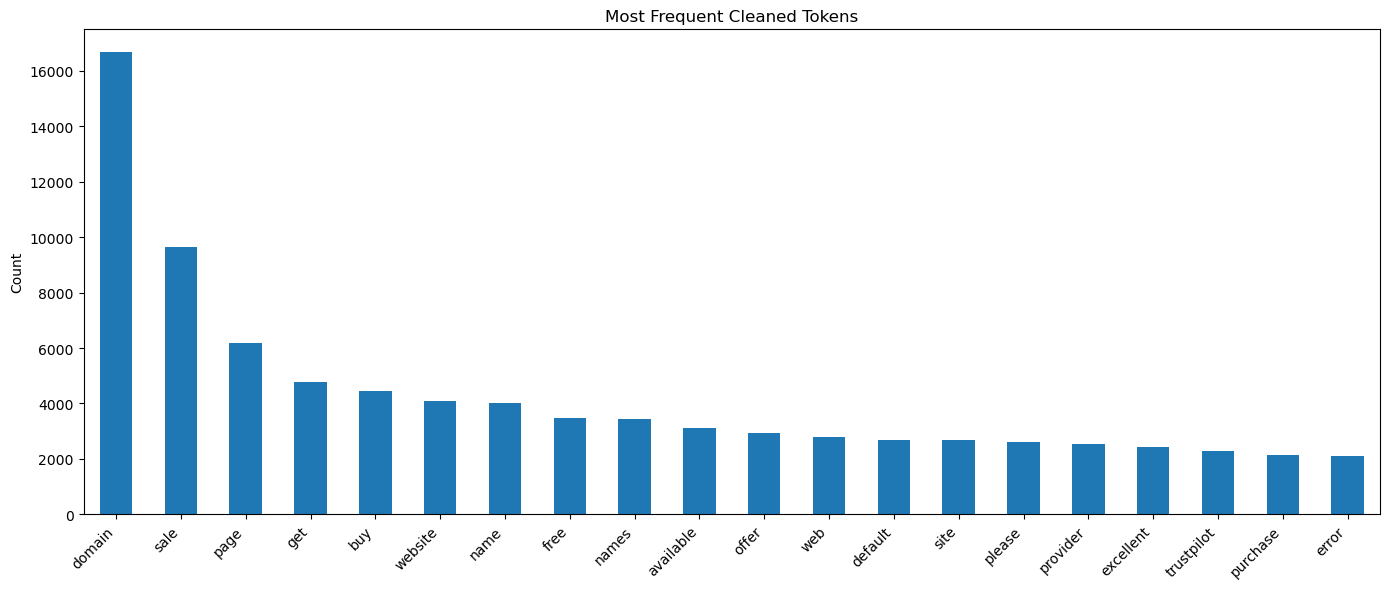

In [8]:
plt.figure(figsize=(14, 6))
token_counts.plot(kind="bar")
plt.title("Most Frequent Cleaned Tokens")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
'''
bag of words and term frequency
'''

def compute_bow(tokens):
    return Counter(tokens)

def compute_tf(bow):
    total_tokens = sum(bow.values())
    return {word: count / total_tokens for word, count in bow.items()}

combined_df["bow"] = combined_df["tokens"].apply(compute_bow)
combined_df["tf"] = combined_df["bow"].apply(compute_tf)
combined_df[["bow", "tf"]].head()

,bow,tf
0,"{'bald': 2, 'verf': 2, 'gbar': 2}","{'bald': 0.3333333333333333, 'verf': 0.3333333..."
1,"{'connect': 3, 'domain': 4, 'almost': 1, 'done...","{'connect': 0.16666666666666666, 'domain': 0.2..."
2,"{'lola': 3, 'estilo': 3, 'abertura': 2, 'em': ...","{'lola': 0.08823529411764706, 'estilo': 0.0882..."
3,{'petrenko': 2},{'petrenko': 1.0}
4,"{'moment': 2, 'verifying': 1, 'human': 1, 'may...","{'moment': 0.15384615384615385, 'verifying': 0..."


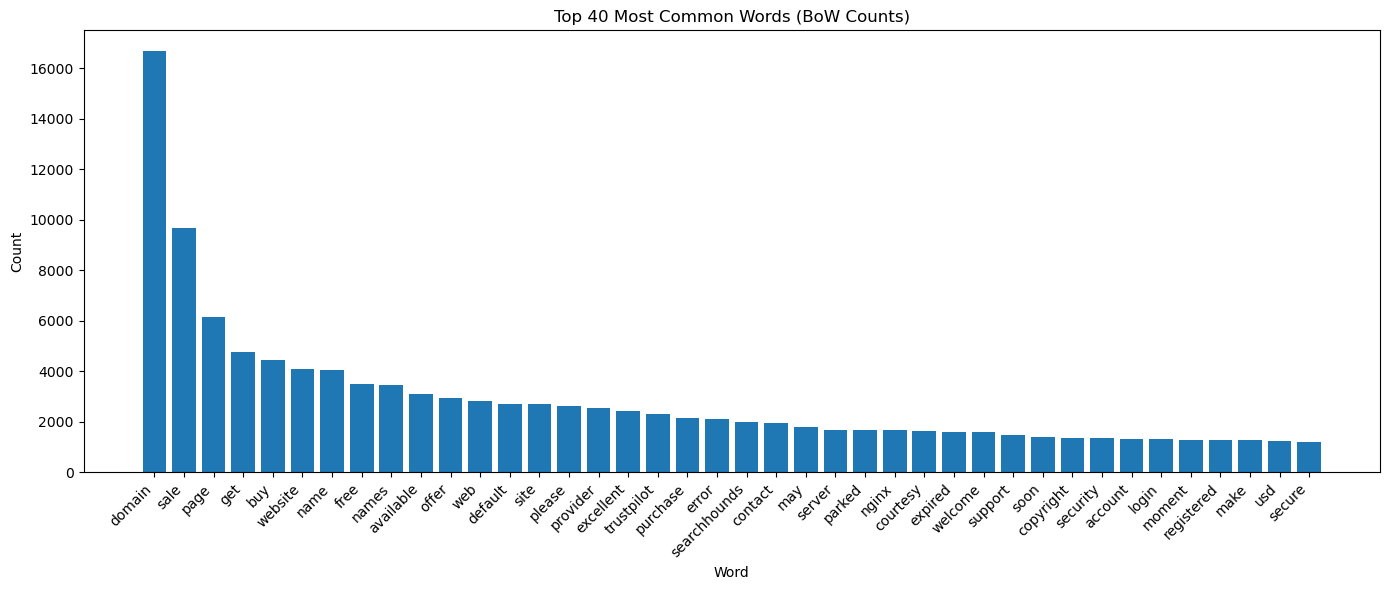

In [10]:
'''
Distribution of term frequencies
'''
# Aggregate all "bag of words" most common words
total_bow = Counter()

for bow in combined_df["bow"]:
    total_bow.update(bow)

# Display top N terms
top_n = 40
top_terms = total_bow.most_common(top_n)
top_df = pd.DataFrame(top_terms, columns=["term", "count"])

# Plot
plt.figure(figsize=(14, 6))
plt.bar(top_df["term"], top_df["count"])
plt.title(f"Top {top_n} Most Common Words (BoW Counts)")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

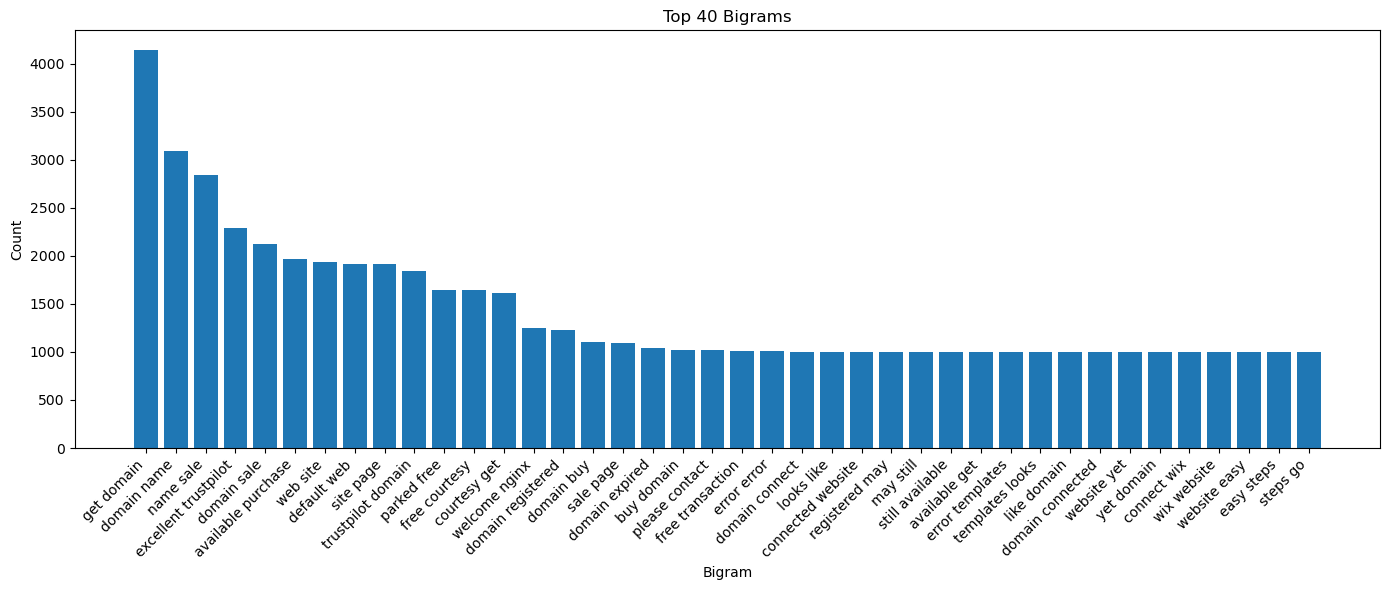

In [11]:
'''
Generate bigrams
'''

def get_bigrams(tokens):
    return list(zip(tokens, tokens[1:]))

# Create bigrams column
combined_df["bigrams"] = combined_df["tokens"].apply(get_bigrams)

total_bigrams = Counter()

for bigram_list in combined_df["bigrams"]:
    total_bigrams.update(bigram_list)


top_n = 40
top_bigrams = total_bigrams.most_common(top_n)

top_df = pd.DataFrame(top_bigrams, columns=["bigram", "count"])
top_df["bigram"] = top_df["bigram"].apply(lambda x: " ".join(x))

plt.figure(figsize=(14, 6))
plt.bar(top_df["bigram"], top_df["count"])
plt.title(f"Top {top_n} Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

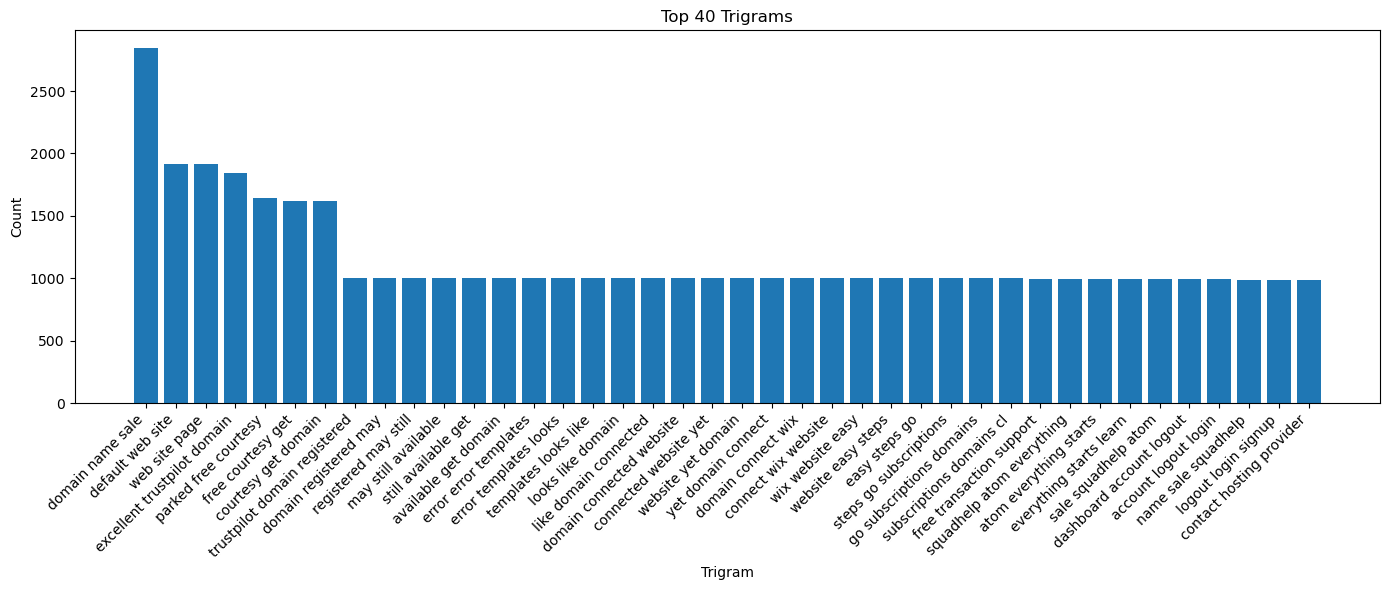

In [12]:
'''
Generate trigrams
'''

def get_trigrams(tokens):
    return list(zip(tokens, tokens[1:], tokens[2:]))

# Create trigrams column
combined_df["trigrams"] = combined_df["tokens"].apply(get_trigrams)

total_trigrams = Counter()

for trigram_list in combined_df["trigrams"]:
    total_trigrams.update(trigram_list)

top_n = 40
top_trigrams = total_trigrams.most_common(top_n)
top_df = pd.DataFrame(top_trigrams, columns=["trigram", "count"])

# Convert tuples to strings
top_df["trigram"] = top_df["trigram"].apply(lambda x: " ".join(x))

plt.figure(figsize=(14, 6))
plt.bar(top_df["trigram"], top_df["count"])
plt.title(f"Top {top_n} Trigrams")
plt.xlabel("Trigram")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
'''
Start of keywords for experimentation
'''
ad_keywords = {
    "ad", "ads", "advertisement", "sponsored", "promotion",
    "click", "offer", "sale", "buy", "discount"
}

parked_keywords = {
    "domain for sale", "buy this domain", "this domain is for sale",
    "parked", "coming soon", "under construction", "related links", "related searches", 
    "search results", "powered by", "ads by", "privacy policy", "this webpage was generated",
    "domain parked free", "listing expired"
}

suspicious_keywords = {
    "virus", "malware", "warning", "security alert", "download now", "install", 
    "verify", "urgent", "your computer", "system alert", "scan now", "risk detected",
    "click here to continue", "enable notifications"
}
print(f"Ad keywords: {len(ad_keywords)}\n", ad_keywords)
print(f"Parked keywords: {len(parked_keywords)}\n", parked_keywords)
print(f"Suspicious keywords: {len(suspicious_keywords)}\n", suspicious_keywords)

Ad keywords: 10
 {'discount', 'click', 'ad', 'promotion', 'sponsored', 'offer', 'sale', 'ads', 'buy', 'advertisement'}
Parked keywords: 15
 {'buy this domain', 'related searches', 'powered by', 'related links', 'this domain is for sale', 'this webpage was generated', 'under construction', 'domain parked free', 'coming soon', 'parked', 'ads by', 'privacy policy', 'listing expired', 'domain for sale', 'search results'}
Suspicious keywords: 14
 {'virus', 'your computer', 'scan now', 'verify', 'click here to continue', 'download now', 'security alert', 'system alert', 'enable notifications', 'urgent', 'risk detected', 'malware', 'install', 'warning'}


In [14]:
'''
Expand on Keywords with bigrams and trigrams
'''

# top n-grams into searchable strings
bigram_list = [" ".join(bg) for bg, _ in total_bigrams.most_common(100)]
trigram_list = [" ".join(tg) for tg, _ in total_trigrams.most_common(100)]

all_ngrams = set(bigram_list + trigram_list)

# Expand keyword sets using pattern matching
def expand_keywords(seed_keywords, ngrams):
    expanded = set(seed_keywords)
    
    for phrase in ngrams:
        for keyword in seed_keywords:
            if keyword in phrase:
                expanded.add(phrase)
    
    return expanded

expanded_ads = expand_keywords(ad_keywords, all_ngrams)
expanded_parked = expand_keywords(parked_keywords, all_ngrams)
expanded_suspicious = expand_keywords(suspicious_keywords, all_ngrams)

print(f"Expanded Ad Keywords: {len(expanded_ads)}\n", expanded_ads)
print(f"\nExpanded Parked Keywords: {len(expanded_parked)}\n", expanded_parked)
print(f"\nExpanded Suspicious Keywords: {len(expanded_suspicious)}\n", expanded_suspicious)

Expanded Ad Keywords: 45
 {'make offer', 'provider click copyright', 'sale free', 'buy add', 'squadhelp atom', 'offer', 'buy', 'click copyright', 'sale please prove', 'ip address', 'domain sale free', 'sale squadhelp atom', 'name sale get', 'sale squadhelp', 'squadhelp atom everything', 'purchase domain sale', 'promotion', 'add watchlist free', 'sale', 'domain name sale', 'identify provider click', 'discount', 'click', 'sale free transaction', 'name sale squadhelp', 'sale please', 'buy domain', 'sponsored', 'domain sale', 'check sale please', 'sale page', 'domain buy', 'advertisement', 'sale get', 'offer buy', 'sale get domain', 'ad', 'provider click', 'name sale', 'sale domain', 'page ip address', 'buy add watchlist', 'ads', 'sale brandbucket', 'security check sale'}

Expanded Parked Keywords: 19
 {'powered by', 'parked free', 'ads by', 'searchhounds parked free', 'search results', 'related searches', 'this domain is for sale', 'domain parked free', 'coming soon', 'parked free courtes

In [15]:
def keyword_score(tokens, keyword_set):
    text = " ".join(tokens)
    return sum(1 for kw in keyword_set if kw in text)

combined_df["ad_score"] = combined_df["tokens"].apply(lambda x: keyword_score(x, expanded_ads))
combined_df["parked_score"] = combined_df["tokens"].apply(lambda x: keyword_score(x, expanded_parked))
combined_df["suspicious_score"] = combined_df["tokens"].apply(lambda x: keyword_score(x, expanded_suspicious))
combined_df[["ad_score", "parked_score", "suspicious_score"]].head(50)


,ad_score,parked_score,suspicious_score
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,1
5,0,0,1
6,0,0,1
7,3,0,0
8,0,0,0
9,5,0,0


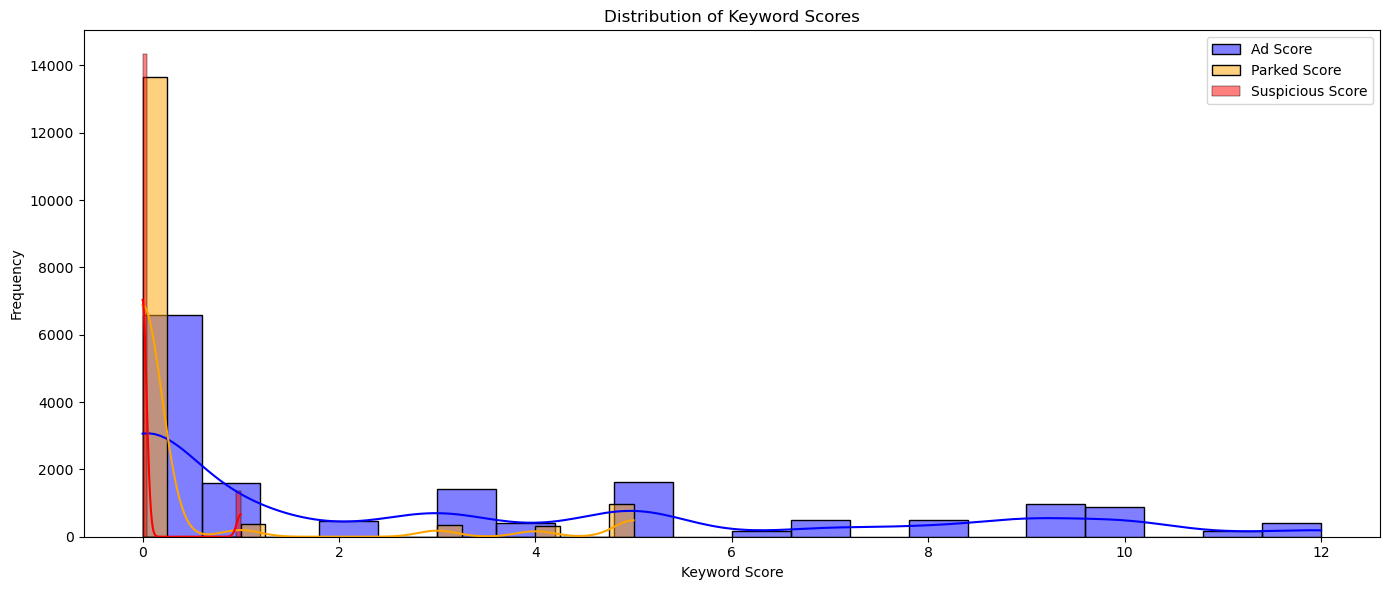

In [16]:
# Analyze score distributions
plt.figure(figsize=(14, 6))
sns.histplot(combined_df["ad_score"], bins=20, kde=True, color="blue", label="Ad Score")
sns.histplot(combined_df["parked_score"], bins=20, kde=True, color="orange", label="Parked Score")
sns.histplot(combined_df["suspicious_score"], bins=20, kde=True, color="red", label="Suspicious Score")
plt.title("Distribution of Keyword Scores")
plt.xlabel("Keyword Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Data Wrangling and Feature engineer

Methodology for parsing urls and the use of shannons entropy came from the following citation:
- Marques C, Malta S, Magalhães JP. DNS dataset for malicious domains detection. Data Brief. 2021 Sep 4;38:107342. doi: 10.1016/j.dib.2021.107342. PMID: 34541265; PMCID: PMC8437788.

The idea to create a similiarty metric for the first and last url came from the following citation (Alrwais et al., 2014, Section 4.1):
- Alrwais, S., Yuan, K., Alowaisheq, E., Li, Z., & Wang, X. (2014). [Understanding the Dark Side of Domain Parking](https://www.usenix.org/system/files/conference/usenixsecurity14/sec14-paper-alrwais.pdf) In Proceedings of the 23rd USENIX Security Symposium (USENIX Security '14). USENIX Association.

In [17]:
'''
extract TLD, domain and subdomain using tldextract

Parse the full domain for analysis.

REMARK: Process is based on the tldextract library, which is a widely used tool for parsing domain names.
'''
# change domain to domain_full to preserve original domain for tldextract
combined_df["domain_full"] = combined_df["domain"]
combined_df.drop("domain", axis=1, inplace=True)

def extract_domain_parts(domain):
    ext = tldextract.extract(domain)
    return pd.Series({
        "subdomain": ext.subdomain,
        "domain_name": ext.domain,
        "tld": ext.suffix
    })

combined_df[["subdomain", "domain_name", "tld"]] = combined_df["domain_full"].apply(extract_domain_parts)

In [ ]:
'''
Predict language using fasttext
'''
# lightweight language identification model

def clean_text_lang(text):
    if not isinstance(text, str):
        return ""
    return text.replace("\n", " ").strip()

def detect_language(text):
    if not isinstance(text, str) or text.strip() == "":
        return "0"

    clean_text = clean_text_lang(text)
    prediction = model.predict(clean_text)
    lang = prediction[0][0].replace("__label__", "")
    confidence = prediction[1][0]

    return lang, confidence

# Apply language to raw_text and split into separate columns
combined_df[["language", "lang_confidence"]] = combined_df["raw_text"].apply(detect_language).apply(pd.Series)

In [ ]:
'''
Is_english flag based on language detection
'''

combined_df["is_english"] = (combined_df["language"] == "en").astype(int)
combined_df[["raw_text", "language", "lang_confidence", "is_english"]].head(20)

In [18]:
'''
domain length feature

Identify how many characters the domain has.
'''
combined_df["len_domain_full"] = combined_df["domain_full"].apply(len)

In [19]:
'''
is_suspicious feature

This feature is derived from the amount of hops (redirects) domain has.
If a domain has more than 2 hops, we can consider it suspicious.
Subject to change based on analysis of hops distribution.
'''
threshold_hops = 2
combined_df["is_suspicious"] = combined_df["hops"].apply(lambda x: 1 if x > threshold_hops else 0)

In [20]:
'''
Analyze redirect chains for domain similarity

Identify potential indicators of suspicious behavior based on domain changes during redirects.
Jaccard similarity to compare token sets of original domain and redirected domains
- 0 is completely different, 1 is identical

Functioning features: 'redirectChain'
'''

def jaccard_similarity(a, b):
    set_a = set(a)
    set_b = set(b)
    
    if not set_a and not set_b:
        return 1.0
    
    return len(set_a & set_b) / len(set_a | set_b)

def domain_to_tokens(parts):
    ''' 
    parts is dict with keys: subdomain, domain_name, tld from extract_domain_parts() function
    '''
    tokens = []
    
    if parts["subdomain"]:
        tokens.extend(parts["subdomain"].split('.'))
    
    if parts["domain_name"]:
        tokens.append(parts["domain_name"])
    
    if parts["tld"]:
        tokens.extend(parts["tld"].split('.'))
    
    return tokens

def analyze_redirect_chain(chain, min_similarity_threshold=0.3):
    if not isinstance(chain, list) or len(chain) == 0:
        return {
            "num_redirects": 0,
            "final_domain": None,
            "avg_redirect_jaccard": 1.0,
            "min_redirect_jaccard": 1.0,
            "low_redirect_similarity_flag": 0
        }
    
    token_sets = []
    
    for step in chain:
        url = step.get("to", "")
        parts = extract_domain_parts(url)
        tokens = domain_to_tokens(parts)
        if tokens:
            token_sets.append(tokens)
    
    if len(token_sets) < 2:
        return {
            "num_redirects": len(chain),
            "final_domain": None,
            "avg_redirect_jaccard": 1.0,
            "min_redirect_jaccard": 1.0,
            "low_redirect_similarity_flag": 0
        }
    
    similarities = []
    
    for i in range(1, len(token_sets)):
        sim = jaccard_similarity(token_sets[i-1], token_sets[i])
        similarities.append(sim)
    
    avg_sim = sum(similarities) / len(similarities)
    min_sim = min(similarities)
    
    # Flag strong domain shift
    low_similarity_flag = int(min_sim < min_similarity_threshold)
    
    final_parts = extract_domain_parts(chain[-1].get("to", ""))
    final_domain = f"{final_parts['domain_name']}.{final_parts['tld']}"
    
    return {
        "num_redirects": len(chain),
        "final_domain": final_domain,
        "avg_redirect_jaccard": avg_sim,
        "min_redirect_jaccard": min_sim,
        "low_redirect_similarity_flag": low_similarity_flag
    }

redirect_features = combined_df["redirectChain"].apply(analyze_redirect_chain)
redirect_df = pd.DataFrame(list(redirect_features))

combined_df = pd.concat([combined_df, redirect_df], axis=1)

In [21]:
'''
Compare original full_domain to last redirected domain usign jaccard similarity.
'''

def original_vs_final_similarity(chain):
    if not chain:
        return 1.0
    
    first = extract_domain_parts(chain[0].get("from", ""))
    last = extract_domain_parts(chain[-1].get("to", ""))
    
    tokens_first = domain_to_tokens(first)
    tokens_last = domain_to_tokens(last)
    
    return jaccard_similarity(tokens_first, tokens_last)

combined_df["first_last_redirect_similarity"] = combined_df["redirectChain"].apply(original_vs_final_similarity)

In [22]:
combined_df.head()

,url,service,hops,redirectChain,finalUrl,title,textSnippet,raw_text,clean_text,tokens,...,domain_name,tld,len_domain_full,is_suspicious,num_redirects,final_domain,avg_redirect_jaccard,min_redirect_jaccard,low_redirect_similarity_flag,first_last_redirect_similarity
0,http://aaa-fuerteventura-appartments.com,other:unclassified,5,[{'from': 'https://aaa-fuerteventura-appartmen...,https://welcome.mywebsite-editor.com/render/ww...,Bald verfügbar,Bald verfügbar,Bald verfügbar Bald verfügbar,bald verf gbar bald verf gbar,"[bald, verf, gbar, bald, verf, gbar]",...,aaa-fuerteventura-appartments,com,33,1,5,mywebsite-editor.com,0.716667,0.200000,1,0.250000
1,http://a-afolienfahrzeuge.at,other:unclassified,3,"[{'from': 'https://a-afolienfahrzeuge.at', 'to...",https://www.a-afolienfahrzeuge.at/,Connect Your Domain,Connect Your Domain You're almost done! Your c...,Connect Your Domain Connect Your Domain You're...,connect domain connect domain almost done cust...,"[connect, domain, connect, domain, almost, don...",...,a-afolienfahrzeuge,at,21,1,3,a-afolienfahrzeuge.at,0.833333,0.666667,0,0.666667
2,http://a-lola-estilo.com,other:unclassified,3,"[{'from': 'https://a-lola-estilo.com', 'to': '...",https://www.a-lola-estilo.com/password,A Lola Estilo – Abertura em breve,A Lola Estilo – Abertura em breve A Lola Estil...,A Lola Estilo – Abertura em breve A Lola Estil...,lola estilo abertura em breve lola estilo aber...,"[lola, estilo, abertura, em, breve, lola, esti...",...,a-lola-estilo,com,17,1,3,a-lola-estilo.com,0.833333,0.666667,0,0.666667
3,http://a-petrenko.com,other:unclassified,3,"[{'from': 'https://a-petrenko.com', 'to': 'htt...",https://a-petrenko.com/info/,a-petrenko,a-petrenko,a-petrenko a-petrenko,petrenko petrenko,"[petrenko, petrenko]",...,a-petrenko,com,14,1,3,a-petrenko.com,1.000000,1.000000,0,1.000000
4,http://a-point-of-view.de,other:unclassified,3,"[{'from': 'https://a-point-of-view.de', 'to': ...",https://p2m-1.forsaledomain.net/true2.php?id=a...,Just a moment...,Just a moment... p2m-1.forsaledomain.net Verif...,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...,"[moment, moment, verifying, human, may, take, ...",...,a-point-of-view,de,18,1,3,forsaledomain.net,0.500000,0.000000,1,0.000000


In [23]:
'''
Shannons entropy of the domain feature

Calculate the Shannon entropy of the domain name to measure its randomness.
Higher entropy MAY indicate a more complex and potentially suspicious domain.
'''
def shannon_entropy(domain):
    if not domain:
        return 0
    
    char_counts = Counter(domain)
    total_chars = sum(char_counts.values())
    
    entropy = -sum((count / total_chars) * log2(count / total_chars) for count in char_counts.values())
    return entropy

# Shannon entropy on full domain name
combined_df["domain_full_entropy"] = combined_df["domain_full"].apply(shannon_entropy)

# Shannon entropy on last redirect domain in redirect chain
combined_df["last_redirect_domain_entropy"] = combined_df["final_domain"].apply(lambda x: shannon_entropy(x) if isinstance(x, str) else 0)

combined_df[["domain_full_entropy", "last_redirect_domain_entropy"]].describe()

,domain_full_entropy,last_redirect_domain_entropy
count,15673.000000,15673.000000
mean,3.245710,1.014863
std,0.342657,1.479851
min,1.121928,0.000000
25%,3.026987,0.000000
50%,3.277613,0.000000
75%,3.500000,2.750000
max,4.163856,4.039610


## Score and Classify Based on Engineered Features

Build a scoring model.

Classify as benign, suspicious, or high risk.

In [24]:
'''
Threat Scoring with isolation forest
- Flags weird combinations of signals
'''

feature_cols = [
    "ad_score",
    "parked_score",
    "suspicious_score",
    "num_redirects",
    "avg_redirect_jaccard",
    "min_redirect_jaccard",
    "low_redirect_similarity_flag",
    "first_last_redirect_similarity",
]

X = combined_df[feature_cols].fillna(0)

In [25]:
'''
Scale Features 
'''
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
'''
K Means Clustering for Suspicious Grouping
'''
kmeans = KMeans(n_clusters=3, random_state=1)
clusters = kmeans.fit_predict(X_scaled)

combined_df["kmeans_cluster"] = clusters

'''
Interpret cluster centers to understand characteristics of each group
cluster with highest suspicious_score, low jaccard means high risk
'''

centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_df = pd.DataFrame(centers, columns=feature_cols)
print(cluster_df)

'''
Measurement of cluster quality using silhouette score
'''
sil_score = silhouette_score(X_scaled, kmeans.labels_)
print(f'Silhouette Score: {sil_score}')

   ad_score  parked_score  suspicious_score  num_redirects  \
0  5.486856  1.151423e-02      1.292635e-01   2.108625e+00   
1  7.208462 -6.661338e-16      8.465451e-16  -1.887379e-15   
2  0.603188  8.865407e-01      8.902007e-02   1.682409e-01   

   avg_redirect_jaccard  min_redirect_jaccard  low_redirect_similarity_flag  \
0              0.208436              0.177048                  9.430806e-01   
1              1.000000              1.000000                  3.275158e-15   
2              0.984701              0.984347                  6.106227e-16   

   first_last_redirect_similarity  
0                        0.177786  
1                        1.000000  
2                        0.984229  
Silhouette Score: 0.4066422456093118


In [27]:
'''
Distance to nearest cluster center
- Find the tightness of clusters and identify potential outliers based on distance to cluster centers.
'''

dist_to_center = np.min(
    cdist(X_scaled, kmeans.cluster_centers_), axis=1
)

combined_df["dist_to_center"] = dist_to_center

In [28]:
'''
Apply Isolation Forest for Anomaly Detection

- Hyperparameters tuning is needed for n_estimators and contamination 
- Tune based on distribution of scores and desired sensitivity
'''
# Hyperparameter grid
n_estimators_grid = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
contamination_grid = [0.01, 0.05, 0.1, 0.15]

results = []

for n in n_estimators_grid:
    for c in contamination_grid:
        iso = IsolationForest(
            n_estimators=n,
            contamination=c,
            random_state=1
        )
        
        preds = iso.fit_predict(X_scaled)  # -1 = anomaly
        
        anomaly_mask = preds == -1
        normal_mask = preds == 1
        
        # Skip bad splits
        if anomaly_mask.sum() == 0 or normal_mask.sum() == 0:
            continue
        
        # Key metric: measure how much farther anomalies are from cluster centers
        # compared to normal points. Higher values indicate better separation
        # between structural outliers and normal data.
        separation = (
            combined_df.loc[anomaly_mask, "dist_to_center"].mean() -
            combined_df.loc[normal_mask, "dist_to_center"].mean()
        )
        
        results.append({
            "n_estimators": n,
            "contamination": c,
            "separation": separation
        })

results_df = pd.DataFrame(results)

In [29]:
print(results_df.sort_values("separation", ascending=False).head(15))

    n_estimators  contamination  separation
36          1000           0.01    2.114135
28           800           0.01    2.099637
4            200           0.01    2.084643
24           700           0.01    2.081876
16           500           0.01    2.081050
32           900           0.01    2.076589
20           600           0.01    2.074639
12           400           0.01    2.072794
8            300           0.01    2.072047
1            100           0.05    2.064558
0            100           0.01    2.055816
29           800           0.05    2.032873
9            300           0.05    2.022827
5            200           0.05    2.013899
13           400           0.05    2.013358


In [30]:
# Best model
best_row = results_df.loc[results_df["separation"].idxmax()]
print(best_row)

# best params for isolation forest
best_iso = IsolationForest(
    n_estimators=int(best_row["n_estimators"]),
    contamination=best_row["contamination"],
    random_state=1
)
best_iso.fit(X_scaled)

# Raw anomaly score (higher = more normal)
raw_scores = best_iso.decision_function(X_scaled)
# Convert to threat score (higher = more risky)
combined_df["iforest_score"] = -raw_scores

n_estimators     1000.000000
contamination       0.010000
separation          2.114135
Name: 36, dtype: float64


In [31]:
'''
Normalize isolation forest threat scores to 
a 0-100 scale.
'''

def normalize_score(x):
    return 100 * (x - x.min()) / (x.max() - x.min())

combined_df["iforest_score_norm"] = normalize_score(combined_df["iforest_score"])
combined_df[["iforest_score", "iforest_score_norm"]].describe()

,iforest_score,iforest_score_norm
count,15673.000000,15673.000000
mean,-0.201222,32.470989
std,0.091335,25.567177
min,-0.317220,0.000000
25%,-0.280288,10.338228
50%,-0.211273,29.657559
75%,-0.138809,49.942095
max,0.040015,100.000000


In [32]:
'''
Risk analysis and scoring for comparison to isolation forest results. 

For future labeling, consider scoring based on isolation forest threat score
    if iforest_score_norm > 0.7:
        label = "high_risk"
    elif iforest_score_norm > 0.4:
        label = "suspicious"
    else:
        label = "benign"
'''

combined_df["behavioral_risk"] = (
    (1 - combined_df["min_redirect_jaccard"]) +
    combined_df["low_redirect_similarity_flag"] +
    combined_df["num_redirects"]
)

combined_df["content_risk"] = (
    combined_df["ad_score"] +
    combined_df["parked_score"] +
    combined_df["suspicious_score"]
)


combined_df["final_score"] = (
    0.6 * normalize_score(combined_df["behavioral_risk"]) +
    0.4 * normalize_score(combined_df["content_risk"])
)

combined_df[["final_score"]].describe()

,final_score
count,15673.000000
mean,23.256862
std,22.168689
min,0.000000
25%,3.333333
50%,16.666667
75%,38.627451
max,75.294118


## Threat Scoring Distributions and Visualizations

These visualizations will give us an interpretable representation of how well our features are capturing the correct signals for scoring and future classification. 

PCA aims to compress the data significantly, into 2 features in our case below (PCA1 and PCA2), and we look to see if the information and structure of our data is being captured. 80% variance means we are keeping major signals that drive the threat scoring framework.

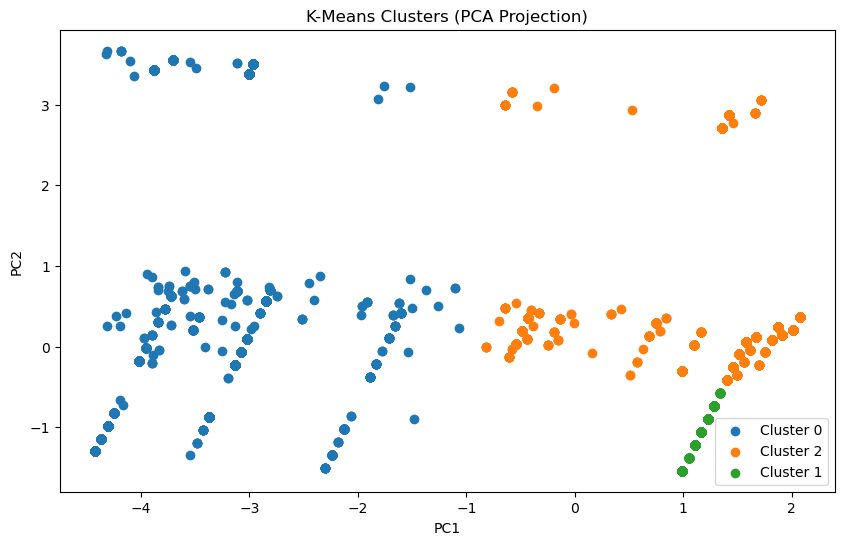

In [33]:
'''
Principal Component Analysis (PCA) for Visualization and Scoring

PCA finds directions (principal components) that capture maximum variance
'''

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = combined_df["kmeans_cluster"]
pca_df["threat_score"] = combined_df["iforest_score_norm"]

# Visualize clusters in PCA space
plt.figure(figsize=(10, 6))
for cluster in pca_df["cluster"].unique():
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}")

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [34]:
'''
about 80% variance retained with 2 components
good for visualization 
may be sufficient for scoring
'''

print(pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

[0.63122544 0.15199798]
Total variance captured: 0.783223414090458


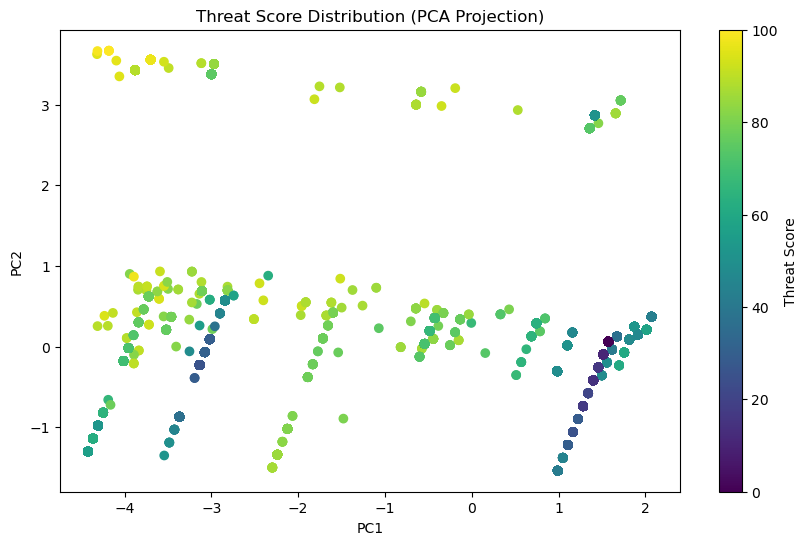

In [35]:
'''
Threat Score Distribution in PCA Space
'''

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["threat_score"]
)

plt.colorbar(scatter, label="Threat Score")
plt.title("Threat Score Distribution (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

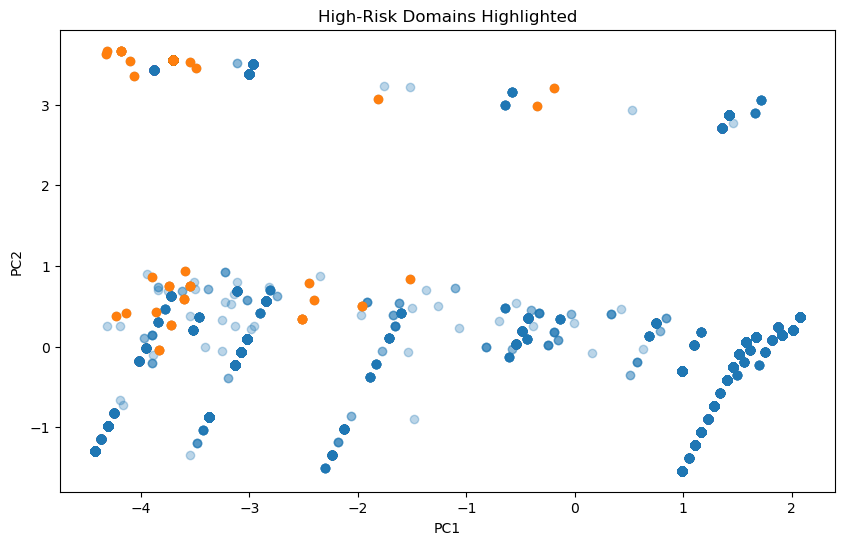

In [36]:
'''
High Risk Domains Highlighted in PCA Space
'''
risk_threshold = 90
high_risk = pca_df[pca_df["threat_score"] > risk_threshold]

plt.figure(figsize=(10, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.3)
plt.scatter(high_risk["PC1"], high_risk["PC2"])

plt.title("High-Risk Domains Highlighted")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Save JSONL

In [37]:
# save as JSONL for future use

# combined_df.to_json('data/parked_suspicious/_combined_data.jsonl', orient='records', lines=True)

In [38]:
combined_df

,url,service,hops,redirectChain,finalUrl,title,textSnippet,raw_text,clean_text,tokens,...,first_last_redirect_similarity,domain_full_entropy,last_redirect_domain_entropy,kmeans_cluster,dist_to_center,iforest_score,iforest_score_norm,behavioral_risk,content_risk,final_score
0,http://aaa-fuerteventura-appartments.com,other:unclassified,5,[{'from': 'https://aaa-fuerteventura-appartmen...,https://welcome.mywebsite-editor.com/render/ww...,Bald verfügbar,Bald verfügbar,Bald verfügbar Bald verfügbar,bald verf gbar bald verf gbar,"[bald, verf, gbar, bald, verf, gbar]",...,0.250000,3.642435,3.684184,0,3.569001,0.010308,91.684295,6.800000,0,60.000000
1,http://a-afolienfahrzeuge.at,other:unclassified,3,"[{'from': 'https://a-afolienfahrzeuge.at', 'to...",https://www.a-afolienfahrzeuge.at/,Connect Your Domain,Connect Your Domain You're almost done! Your c...,Connect Your Domain Connect Your Domain You're...,connect domain connect domain almost done cust...,"[connect, domain, connect, domain, almost, don...",...,0.666667,3.689704,3.689704,2,3.188860,-0.020947,82.935138,3.333333,0,29.411765
2,http://a-lola-estilo.com,other:unclassified,3,"[{'from': 'https://a-lola-estilo.com', 'to': '...",https://www.a-lola-estilo.com/password,A Lola Estilo – Abertura em breve,A Lola Estilo – Abertura em breve A Lola Estil...,A Lola Estilo – Abertura em breve A Lola Estil...,lola estilo abertura em breve lola estilo aber...,"[lola, estilo, abertura, em, breve, lola, esti...",...,0.666667,3.292770,3.292770,2,3.188860,-0.020947,82.935138,3.333333,0,29.411765
3,http://a-petrenko.com,other:unclassified,3,"[{'from': 'https://a-petrenko.com', 'to': 'htt...",https://a-petrenko.com/info/,a-petrenko,a-petrenko,a-petrenko a-petrenko,petrenko petrenko,"[petrenko, petrenko]",...,1.000000,3.521641,3.521641,2,2.932009,-0.057444,72.718443,3.000000,0,26.470588
4,http://a-point-of-view.de,other:unclassified,3,"[{'from': 'https://a-point-of-view.de', 'to': ...",https://p2m-1.forsaledomain.net/true2.php?id=a...,Just a moment...,Just a moment... p2m-1.forsaledomain.net Verif...,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...,"[moment, moment, verifying, human, may, take, ...",...,0.000000,3.572431,3.616875,0,3.701336,0.029177,96.966248,5.000000,1,47.450980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15668,http://academialaplace.com,other:hosting-es,0,[],https://academialaplace.com/,Academia Preuniversitaria Laplace | Arequipa,Academia Preuniversitaria Laplace | Arequipa 🚧...,Academia Preuniversitaria Laplace | Arequipa A...,academia preuniversitaria laplace arequipa aca...,"[academia, preuniversitaria, laplace, arequipa...",...,1.000000,3.070847,0.000000,2,0.753669,-0.280288,10.338228,0.000000,1,3.333333
15669,http://bartender-guides.com,dan,4,"[{'from': 'https://bartender-guides.com', 'to'...",https://www.afternic.com/?origin=dancom,Sell Domains | Buy Domains | Park Domains - Af...,Sell Domains | Buy Domains | Park Domains - Af...,Sell Domains | Buy Domains | Park Domains - Af...,sell domains buy domains park domains afternic...,"[sell, domains, buy, domains, park, domains, a...",...,0.250000,3.884184,3.418296,0,3.120890,0.004864,90.160360,4.666667,2,47.843137
15670,http://beautyquette.com,dan,4,"[{'from': 'https://beautyquette.com', 'to': 'h...",https://www.afternic.com/?origin=dancom,Sell Domains | Buy Domains | Park Domains - Af...,Sell Domains | Buy Domains | Park Domains - Af...,Sell Domains | Buy Domains | Park Domains - Af...,sell domains buy domains park domains afternic...,"[sell, domains, buy, domains, park, domains, a...",...,0.250000,3.280639,3.418296,0,3.120890,0.004864,90.160360,4.666667,2,47.843137
15671,http://beech-mountain.com,dan,4,"[{'from': 'https://beech-mountain.com', 'to': ...",https://www.afternic.com/?origin=dancom,Sell Domains | Buy Domains | Park Domains - Af...,Sell Domains | Buy Domains | Park Domains - Af...,Sell Domains | Buy Domains | Park Domains - 